In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the server data and ground truth labels
# cv_server_data.csv contains the features (Latency and Throughput)
# gt_server_data.csv contains the labels (0 = Normal, 1 = Anomaly)
X_data = pd.read_csv('/content/drive/MyDrive/Machine Learning Lab/Anomally detection/cv_server_data.csv', header=None, names=['Latency', 'Throughput'])
y_data = pd.read_csv('/content/drive/MyDrive/Machine Learning Lab/Anomally detection/gt_server_data.csv', header=None, names=['Class'])

# Combine into a single DataFrame for easier handling
df = pd.concat([X_data, y_data], axis=1)

print("Data loaded successfully!")
print("-" * 30)
print(df.head())
print("\nClass distribution:")
print(df['Class'].value_counts())

Data loaded successfully!
------------------------------
   Latency  Throughput  Class
0   15.790      14.921      0
1   13.640      15.330      0
2   14.866      16.474      0
3   13.585      13.989      0
4   13.464      15.635      0

Class distribution:
Class
0    298
1      9
Name: count, dtype: int64


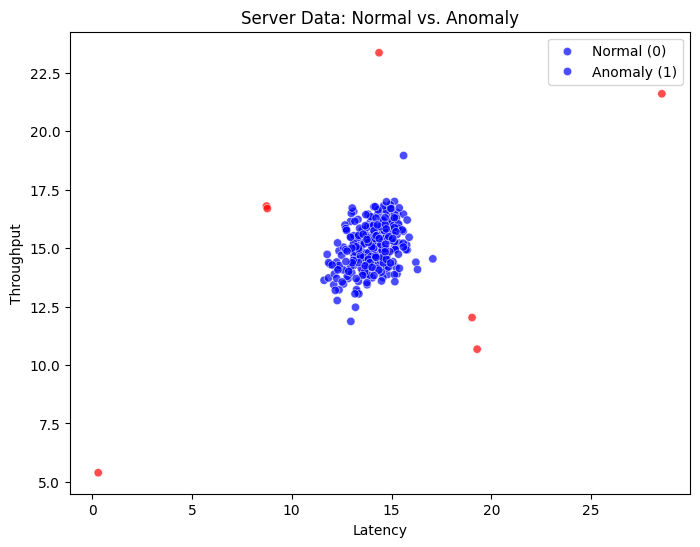

In [4]:
# Visualizing the distribution of normal vs anomalous server behavior
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Latency', y='Throughput', hue='Class', data=df,
                palette={0: 'blue', 1: 'red'}, alpha=0.7)

plt.title('Server Data: Normal vs. Anomaly')
plt.xlabel('Latency')
plt.ylabel('Throughput')
plt.legend(['Normal (0)', 'Anomaly (1)'])
plt.show()

In [5]:
# Defining Feature Matrix (X) and Target Variable (y)
X = df[['Latency', 'Throughput']]
y = df['Class']

print(f"Feature Matrix X shape: {X.shape}")
print(f"Target y shape: {y.shape}")

Feature Matrix X shape: (307, 2)
Target y shape: (307,)


In [6]:
from sklearn.model_selection import train_test_split

# Splitting the data 80% for training and 20% for testing
# stratify=y ensures the anomaly ratio is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (245, 2)
Testing data shape: (62, 2)


In [7]:
from sklearn.preprocessing import StandardScaler

# Initializing the scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete. Data is standardized.")

Feature scaling complete. Data is standardized.


In [8]:
from sklearn.ensemble import IsolationForest

# Initializing the Isolation Forest model
# We estimate the contamination rate based on the training set's known anomaly ratio
contamination_rate = y_train.mean()
model = IsolationForest(contamination=contamination_rate, random_state=42)

# Training the model
model.fit(X_train_scaled)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [9]:
# Making predictions on the test set
raw_predictions = model.predict(X_test_scaled)

# Isolation Forest outputs 1 for normal (inliers) and -1 for anomalies (outliers)
# We map these back to our target format: 0 for normal, 1 for anomaly
y_pred = np.where(raw_predictions == 1, 0, 1)

print("Predictions generated and mapped to 0 (Normal) and 1 (Anomaly).")

Predictions generated and mapped to 0 (Normal) and 1 (Anomaly).


Accuracy: 98.39%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       1.00      0.50      0.67         2

    accuracy                           0.98        62
   macro avg       0.99      0.75      0.83        62
weighted avg       0.98      0.98      0.98        62



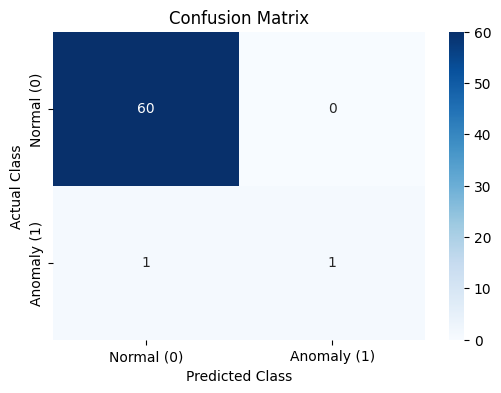

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# 2. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

In [11]:
# Creating new sample data points to test the system
# Sample 1: Values within typical ranges observed in the dataset
# Sample 2: Extreme latency and low throughput
new_samples = pd.DataFrame([
    [14.0, 15.0],
    [22.5, 4.2]
], columns=['Latency', 'Throughput'])

# Step A: Scale the new data using the previously fitted scaler
new_samples_scaled = scaler.transform(new_samples)

# Step B: Make predictions
new_raw_preds = model.predict(new_samples_scaled)

# Step C: Map results to readable text
new_preds_mapped = np.where(new_raw_preds == 1, "Normal", "Anomaly")

print("--- New Sample Predictions ---")
for i, pred in enumerate(new_preds_mapped):
    print(f"Sample {i+1} (Latency: {new_samples.iloc[i,0]}, Throughput: {new_samples.iloc[i,1]}) prediction: {pred}")

--- New Sample Predictions ---
Sample 1 (Latency: 14.0, Throughput: 15.0) prediction: Normal
Sample 2 (Latency: 22.5, Throughput: 4.2) prediction: Anomaly
